# 02 — Training, Evaluation & Safeguards

Τι απαντάει αυτό το notebook, με τη σειρά:

1. **Split** — group-aware ανά κείμενο, ώστε το test να μη μετράει απομνημόνευση.
2. **Εκπαίδευση** — TF-IDF ανά πεδίο, brand ως categorical, LightGBM.
3. **Αξιολόγηση** — macro F1, confusion matrix, τα κυρίαρχα λάθη.
4. **Calibration** — Platt, ώστε το `p_max` να είναι πραγματική πιθανότητα.
5. **Safeguard** — κανόνας κόστους AUTO ή REVIEW, με πίνακα ευαισθησίας.
6. **Interpretability** — feature importance με split και gain, και SHAP πάνω στα λάθη «1049 ως 5».

Οι αποφάσεις και τα «γιατί» βρίσκονται στο `REPORT.md`.

> **Σημείωση για το calibration.** Πρώτα δοκιμάστηκε `method="isotonic"`, αλλά το
> macro F1 έπεφτε ενώ το accuracy έμενε ίδιο — σημάδι ότι η ζημιά ήταν στις μικρές
> κλάσεις, που έχουν μόλις 22 έως 39 προϊόντα στο σύνολο βαθμονόμησης και δεν
> επαρκούν για μη παραμετρική μέθοδο.
>
> Εκπαιδεύσαμε μία φορά και βαθμονομήσαμε με τις δύο μεθόδους (experiment 04): το
> Platt (`sigmoid`) ανέβασε το macro F1 σε 0,9842 και μείωσε τα λάθη που φτάνουν
> στο κατάστημα από 24 σε 10, με την κλάση 7 να επανέρχεται από 0,935 σε 0,990.
> Τεκμηρίωση: `REPORT.md` §7.3 και `docs/experiment_04_calibration.csv`.

In [1]:
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, f1_score, matthews_corrcoef
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

TARGET_COLUMN = "category"
TEXT_COLUMNS = ["product_name", "product_description", "features"]
RANDOM_STATE = 42

## 0. Φόρτωση

In [2]:
data = pd.read_csv("../data/proc/proc_products.csv").drop_duplicates()
data[TEXT_COLUMNS] = data[TEXT_COLUMNS].fillna("")
data[TARGET_COLUMN] = data[TARGET_COLUMN].astype(int)

print("rows after dedup:", f"{len(data):,}")

rows after dedup: 101,204


## 1. Group split: train / calibration / test

Όλες οι παραλλαγές με ίδιο `description + features` πάνε **μαζί** στο ίδιο σύνολο → δεν υπάρχει leakage.
- **test** 20%: τελική αξιολόγηση, μένει με αντίγραφα όπως στην παραγωγή
- **calibration** 15% του υπόλοιπου: μόνο για τη διόρθωση των πιθανοτήτων ???
- **train**: τα υπόλοιπα

In [3]:
text_groups = data.groupby(["product_description", "features"]).ngroup()

splitter_test = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
theseis_ekpaideusis, idx_test = next(splitter_test.split(data, groups=text_groups))
data_fitting = data.iloc[theseis_ekpaideusis]
data_test = data.iloc[idx_test]

splitter_calibration = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=RANDOM_STATE)
theseis_train, idx_calibration = next(
    splitter_calibration.split(data_fitting, groups=text_groups.iloc[theseis_ekpaideusis])
)
data_train = data_fitting.iloc[theseis_train]
data_calibration = data_fitting.iloc[idx_calibration]

shared_groups = set(text_groups.loc[data_train.index]) & set(text_groups.loc[data_test.index])
print(f"train: {len(data_train):,} | calibration: {len(data_calibration):,} | test: {len(data_test):,}")
print("shared text groups between train and test (must be 0):", len(shared_groups))

train: 69,664 | calibration: 11,614 | test: 19,926
shared text groups between train and test (must be 0): 0


## 2. Features + μοντέλο

- **brand**: `OrdinalEncoder(min_frequency=20)`: brands με < 20 προϊόντα μπαίνουν σε κοινή κατηγορία "σπάνιο". Είναι **πρώτη** στήλη, για να δηλωθεί ως categorical στο LightGBM (`categorical_feature=[0]`).
- **ένα TF-IDF ανά πεδίο**: unigrams + bigrams (`"machine wash"`), χωρίς αγγλικά stop words.
- **LightGBM**: παράμετροι από το model-mltagging, `class_weight="balanced"` επειδή όλες οι κλάσεις είναι ίσης σημασίας.

In [4]:
tfidf_settings = dict(ngram_range=(1, 2), min_df=3, max_features=10_000, sublinear_tf=True, stop_words="english")

feature_transformer = ColumnTransformer(
    [
        ("brand", OrdinalEncoder(min_frequency=20, handle_unknown="use_encoded_value", unknown_value=-1), ["brand"]),
        ("name", TfidfVectorizer(**tfidf_settings), "product_name"),
        ("description", TfidfVectorizer(**tfidf_settings), "product_description"),
        ("features", TfidfVectorizer(**tfidf_settings), "features"),
    ]
)

model = Pipeline(
    [
        ("features", feature_transformer),
        (
            "lgbm",
            LGBMClassifier(
                class_weight="balanced",
                n_estimators=200,
                learning_rate=0.05,
                num_leaves=63,
                min_child_samples=15,
                subsample=0.75,
                subsample_freq=1,
                reg_lambda=0.1,
                max_bin=60,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbose=-1,
            ),
        ),
    ]
)

In [5]:
started = time.time()
model.fit(data_train, data_train[TARGET_COLUMN], lgbm__categorical_feature=[0])
print(f"training time: {time.time() - started:.0f} s")

training time: 248 s


## 3. Αξιολόγηση στο test

Κύρια μετρική **macro F1**: κάθε κλάση μετράει το ίδιο, όσο μικρή κι αν είναι.

In [6]:
y_true = data_test[TARGET_COLUMN].to_numpy()
predictions = model.predict(data_test)

print(f"macro F1: {f1_score(y_true, predictions, average='macro'):.4f}")
print(f"MCC:      {matthews_corrcoef(y_true, predictions):.4f}")
print()
print(classification_report(y_true, predictions, digits=3))

macro F1: 0.9827
MCC:      0.9700

              precision    recall  f1-score   support

           0      0.963     0.993     0.978       451
           1      1.000     0.994     0.997       320
           3      1.000     0.940     0.969        67
           5      0.988     0.991     0.989     13130
           7      1.000     1.000     1.000        49
           9      0.968     0.968     0.968       124
        1049      0.968     0.960     0.964      3873
        1053      0.990     0.976     0.983       210
        1313      0.996     0.991     0.993      1670
        1842      0.970     1.000     0.985        32

    accuracy                          0.984     19926
   macro avg      0.984     0.981     0.983     19926
weighted avg      0.984     0.984     0.984     19926



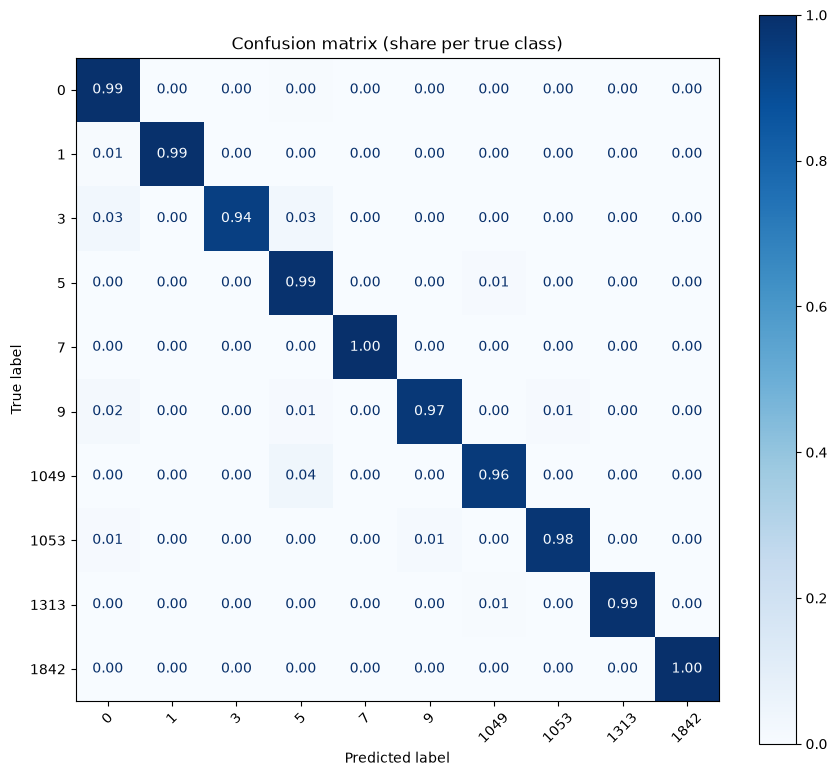

In [7]:
fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay.from_predictions(
    y_true, predictions, normalize="true", values_format=".2f", xticks_rotation=45, cmap="Blues", ax=ax
)
ax.set_title("Confusion matrix (share per true class)")
plt.tight_layout()

## 4. Calibration

Το LightGBM (ειδικά με `class_weight="balanced"`) βγάζει παραμορφωμένες πιθανότητες. Το calibration, πάνω σε **ξεχωριστό** σύνολο, τις διορθώνει ώστε "95%" να σημαίνει πραγματικά ~95% σωστά. Χωρίς αυτό, το κατώφλι του safeguard δεν έχει νόημα.

Χρησιμοποιείται **Platt (`sigmoid`)**. Το `isotonic` δοκιμάστηκε και απορρίφθηκε: είναι μη παραμετρικό και υπερπροσαρμόζει στις κλάσεις με λίγα δείγματα βαθμονόμησης (βλ. σημείωση στην αρχή).

`FrozenEstimator`: το μοντέλο δεν ξαναεκπαιδεύεται, βαθμονομούνται μόνο οι πιθανότητές του.

In [8]:
calibrated_model = CalibratedClassifierCV(FrozenEstimator(model), method="sigmoid")
calibrated_model.fit(data_calibration, data_calibration[TARGET_COLUMN])

probabilities = calibrated_model.predict_proba(data_test)
predictions_calibrated = calibrated_model.classes_[probabilities.argmax(axis=1)]
max_probability = probabilities.max(axis=1)

confidence_bins = pd.cut(max_probability, [0, 0.5, 0.8, 0.9, 0.95, 0.99, 1.0])
calibration_check = pd.DataFrame(
    {"sigouria_bin": confidence_bins, "correct_mask": predictions_calibrated == y_true, "pithanotita": max_probability}
).groupby("sigouria_bin", observed=True).agg(count=("correct_mask", "size"), mean_probability=("pithanotita", "mean"), actual_accuracy=("correct_mask", "mean"))
calibration_check.round(3)

,count,mean_probability,actual_accuracy
sigouria_bin,,,
"(0.0, 0.5]",87,0.423,0.943
"(0.5, 0.8]",550,0.652,0.751
"(0.8, 0.9]",427,0.861,0.927
"(0.9, 0.95]",694,0.928,0.929
"(0.95, 0.99]",3202,0.978,0.982
"(0.99, 1.0]",14966,0.997,0.999


Σωστό calibration: η `mesi_pithanotita` ≈ `pragmatiki_akriveia` σε κάθε γραμμή.

## 5. Production safeguard: AUTO / REVIEW

### 5.1 Υποθέσεις κόστους (ενδεικτικές, δεν δόθηκαν πραγματικά κόστη)

- **Review:** 20 δευτερόλεπτα ανά προϊόν επί 10 ευρώ την ώρα, δηλαδή 0,056 ευρώ
- **Λάθος κατηγοριοποίηση:** 1 ευρώ (χαμένες πωλήσεις και churn πελάτη)
- **Κανόνας:** AUTO αν `(1 − p_max) × κόστος_λάθους ≤ κόστος_review`, δηλαδή `p_max ≥ 1 − 0,056 / 1 = 0,9444`
- Όλες οι κλάσεις ίσης σημασίας, άρα **ένα** κατώφλι για όλες.

In [9]:
SECONDS_PER_REVIEW = 20
REVIEWER_COST_PER_HOUR_EUR = 10
ERROR_COST_EUR = 1

COST_REVIEW = SECONDS_PER_REVIEW / 3600 * REVIEWER_COST_PER_HOUR_EUR
COST_ERROR = ERROR_COST_EUR


def decide_auto(probabilities: np.ndarray, cost_error: float, kostos_review: float) -> np.ndarray:
    """True = AUTO, False = REVIEW. AUTO when the expected cost of an error does not exceed the cost of a review."""
    expected_cost_auto = (1 - probabilities.max(axis=1)) * cost_error
    return expected_cost_auto <= kostos_review


is_auto = decide_auto(probabilities, COST_ERROR, COST_REVIEW)
correct_in_auto = predictions_calibrated[is_auto] == y_true[is_auto]

print(f"threshold: p_max at least {1 - COST_REVIEW / COST_ERROR:.4f}")
print(f"AUTO:   {is_auto.mean():.1%} of products | precision on AUTO: {correct_in_auto.mean():.2%}")
print(f"REVIEW: {(~is_auto).mean():.1%} of products")
print(f"errors reaching the storefront: {(~correct_in_auto).sum()} out of {len(y_true):,}")

threshold: p_max at least 0.9444
AUTO:   91.7% of products | precision on AUTO: 99.55%
REVIEW: 8.3% of products
errors reaching the storefront: 83 out of 19,926


### 5.2 Πίνακας ευαισθησίας

Η επιχείρηση διαλέγει το trade-off: όσο ακριβότερο το λάθος σε σχέση με το review, τόσο αυστηρότερο το κατώφλι, άρα περισσότερο review και λιγότερα λάθη.

In [10]:
sensitivity_rows = []
for cost_ratio in [5, 10, 20, 50, 100, 180, 500]:
    auto_in_scenario = decide_auto(probabilities, cost_ratio * COST_REVIEW, COST_REVIEW)
    correct = predictions_calibrated[auto_in_scenario] == y_true[auto_in_scenario]
    sensitivity_rows.append(
        {
            "cost_error / kostos_review": cost_ratio,
            "threshold": round(1 - 1 / cost_ratio, 4),
            "auto_share": round(auto_in_scenario.mean(), 3),
            "precision_on_auto": round(correct.mean(), 4),
            "storefront_errors": int((~correct).sum()),
        }
    )
pd.DataFrame(sensitivity_rows)

,cost_error / kostos_review,threshold,auto_share,precision_on_auto,storefront_errors
0,5,0.8000,0.968,0.9918,159
1,10,0.9000,0.947,0.9932,128
2,20,0.9500,0.912,0.9957,79
3,50,0.9800,0.841,0.9974,44
4,100,0.9900,0.751,0.9985,22
5,180,0.9944,0.633,0.9992,10
6,500,0.9980,0.213,0.9995,2


In [11]:
auto_per_class = pd.DataFrame({"cls": y_true, "auto": is_auto}).groupby("cls")["auto"].agg(count="size", auto_share="mean")
auto_per_class.sort_values("auto_share").round(3)

,count,auto_share
cls,,
7,49,0.796
3,67,0.806
1049,3873,0.820
9,124,0.879
1313,1670,0.920
5,13130,0.943
1053,210,0.957
1,320,0.966
1842,32,0.969


## 6. Error analysis

### 6.1 Συχνότερα μπερδέματα (αληθινή κατηγορία και τι προβλέφθηκε)

In [12]:
confusion_pairs = pd.crosstab(
    pd.Series(y_true, name="true_class"), pd.Series(predictions_calibrated, name="predicted")
).stack()
errors_only = confusion_pairs[
    confusion_pairs.index.get_level_values("true_class") != confusion_pairs.index.get_level_values("predicted")
]

test_class_size = pd.Series(y_true).value_counts()
top_confusions = errors_only.sort_values(ascending=False).head(10).reset_index(name="count")
top_confusions["pososto_tis_alithinis_klasis"] = (
    top_confusions["count"] / top_confusions["true_class"].map(test_class_size)
).round(3)
top_confusions

,true_class,predicted,count,pososto_tis_alithinis_klasis
0,1049,5,171,0.044
1,5,1049,81,0.006
2,1049,1313,8,0.002
3,5,0,7,0.001
4,1313,1049,6,0.004
5,1313,5,6,0.004
6,1049,0,3,0.001
7,3,0,2,0.030
8,1,0,2,0.006
9,3,5,2,0.030


### 6.2 Σίγουρα λάθη: τα πιο επικίνδυνα για το UX

Λάθος πρόβλεψη **και** πάνω από το κατώφλι, δηλαδή θα περνούσαν στο κατάστημα χωρίς review.

In [13]:
test_with_predictions = data_test.assign(
    predicted=predictions_calibrated, p_max=max_probability.round(4), auto=is_auto
)
confident_errors = test_with_predictions[(test_with_predictions["predicted"] != test_with_predictions[TARGET_COLUMN]) & test_with_predictions["auto"]]

print(f"confident errors: {len(confident_errors)}")
confident_errors[["product_name", "brand", TARGET_COLUMN, "predicted", "p_max"]].sort_values("p_max", ascending=False).head(20)

confident errors: 83


,product_name,brand,category,predicted,p_max
98523,FLEXIMAA Men's Slim Fit T-Shirt (prwmagentaloo...,FLEXIMAA,1049,5,0.9984
72867,FLEXIMAA Men's Slim Fit T-Shirt (prwbluesmile-...,FLEXIMAA,1049,5,0.9984
1379,Republic of Gamers X-Games Rog Glitch Eye T-Sh...,Republic of Gamers,1049,5,0.9963
47648,RS PRINT Mr Right Mrs Always Right Printed Mat...,RS PRINT,1049,5,0.9955
24500,RS PRINT Mr Right Mrs Always Right Printed Mat...,RS PRINT,1049,5,0.9955
16821,RS PRINT Mr Right Mrs Always Right Printed Mat...,RS PRINT,1049,5,0.9955
49092,RS PRINT Mr Right Mrs Always Right Printed Mat...,RS PRINT,1049,5,0.9955
59892,Swangiya 111 T.Shirt-Black-XXL,Swangiya,1049,5,0.9951
31963,Swangiya 111 T.Shirt-rama-L,Swangiya,1049,5,0.9947
22204,Swangiya 111 T.Shirt,Swangiya,1049,5,0.9947


### 6.3 Λάθη ανά μπέρδεμα: παραδείγματα από το συχνότερο

In [14]:
top_confusion = top_confusions.iloc[0]
examples = test_with_predictions[
    (test_with_predictions[TARGET_COLUMN] == top_confusion["true_class"])
    & (test_with_predictions["predicted"] == top_confusion["predicted"])
]
print(f"true {top_confusion['true_class']} predicted as {top_confusion['predicted']}: {len(examples)} errors")
examples[["product_name", "brand", "p_max"]].head(15)

true 1049.0 predicted as 5.0: 171 errors


,product_name,brand,p_max
1003,dibiya Half Sleeve White and Black Combo Pack ...,dibiya,0.9041
1004,bbrave Men & Women Regular Fit T Shirt,bbrave,0.8708
1058,HeartInk Men & Women Pink Raglan Sleeve Cotton...,HeartInk,0.9276
1351,fUNKYcLOSET - Coldplay Viva La Vida T-Shirt - ...,fUNKYcLOSET,0.9560
1379,Republic of Gamers X-Games Rog Glitch Eye T-Sh...,Republic of Gamers,0.9963
1533,DOLLARTREE Stripe Pocket Pooh Print Design t-S...,DOLLARTREE,0.5678
2347,PARTUM CORDE Indira Gandhi T Shirt (Pink ; X-L...,PARTUM CORDE,0.9585
2361,Radical Inborn Ace Queen,Generic,0.6887
2642,LIME Solid Slim fit Cotton High Neck Long Slee...,LIME,0.6092
2657,Hangout Hub Family Mom Son- Women's & Boy's Co...,Hangout Hub,0.5609


## 7. Interpretability

Τρεις οπτικές στο ίδιο ερώτημα, «τι οδηγεί τις προβλέψεις», από το γενικό στο ειδικό:

| Εργαλείο | Τι απαντάει | Σε τι εφαρμόζεται |
|---|---|---|
| `split` και `gain` | πόσο συχνά χρησιμοποιήθηκε ένα πεδίο και πόσο βοήθησε | όλο το μοντέλο |
| `lgb.plot_importance` | ποιοι 20 όροι κουβαλάνε το περισσότερο gain | όλο το μοντέλο |
| SHAP | ποιες λέξεις ζυγίζουν μέσα σε ένα συγκεκριμένο είδος λάθους | δείγμα λαθών |

Κάθε γραμμή είναι ένα εργαλείο, η δεύτερη στήλη το ερώτημα που απαντάει και η τρίτη η εμβέλειά του.

Το importance λέει τι χρησιμοποιεί το μοντέλο συνολικά, αλλά όχι τι φταίει σε ένα συγκεκριμένο μπέρδεμα. Το SHAP περιορισμένο στα λάθη «1049 ως 5» το απαντάει.

Η πρακτική αξία δεν είναι ακαδημαϊκή: η ανάλυση των λαθών θέλει να ξεχωρίσει το «αδύναμο μοντέλο» από το «ασαφείς ετικέτες», και η απάντηση αλλάζει το τι κάνεις μετά — καλύτερος αλγόριθμος ή κανόνας καταχώρησης.

### 7.1 Feature importance: split και gain

Δύο μετρήσεις, γιατί απαντάνε σε διαφορετικά ερωτήματα:

- **split**: πόσο **συχνά** ένα feature χώρισε κόμβο. Ευνοεί τα features με πολλές διακριτές τιμές.
- **gain**: πόσο **βελτιώθηκε** το μοντέλο όταν το έκανε. Πιο κοντά στην πραγματική συνεισφορά.

Το `brand` είναι το παράδειγμα της διαφοράς: χαμηλό και στα δύο, αλλά το ablation (experiment 03) δείχνει ότι χωρίς αυτό τα λάθη «1049 ως 5» εκτοξεύονται. Χαμηλό importance σημαίνει «χρησιμοποιείται σπάνια», όχι «ασφαλές να αφαιρεθεί».

In [15]:
feature_names = model["features"].get_feature_names_out()

importance_split = pd.Series(model["lgbm"].feature_importances_, index=feature_names)
importance_gain = pd.Series(
    model["lgbm"].booster_.feature_importance(importance_type="gain"), index=feature_names
)

pedio_kathe_feature = pd.Index(feature_names).str.split("__").str[0]
importance_per_field = pd.DataFrame(
    {
        "split": importance_split.groupby(pedio_kathe_feature).sum(),
        "gain": importance_gain.groupby(pedio_kathe_feature).sum(),
    }
)
importance_per_field = (importance_per_field / importance_per_field.sum()).sort_values(
    "gain", ascending=False
)

print("total importance per field (split = how often, gain = how much it helped):")
display(importance_per_field.round(3))

importance_split.sort_values(ascending=False).head(25)

total importance per field (split = how often, gain = how much it helped):


,split,gain
name,0.492,0.799
features,0.287,0.099
description,0.210,0.084
brand,0.011,0.019


name__women           1469
name__shirt           1074
brand__brand           873
features__cotton       767
name__men              630
name__set              523
name__black            520
name__pack             516
features__size         499
features__material     462
name__white            442
name__multi            438
name__plant            417
name__blue             408
name__cotton           379
name__womens           368
name__tee              365
name__magnet           358
name__tshirt           354
name__fertilizer       354
features__use          354
features__wash         351
name__large            336
name__magnetic         333
name__seeds            332
dtype: int32

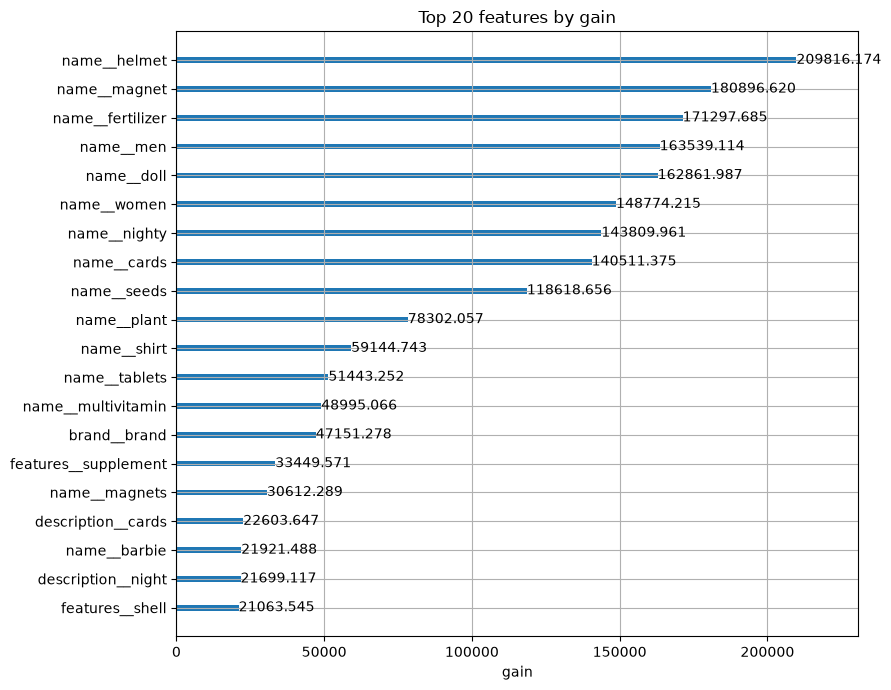

In [16]:
import lightgbm as lgb

ax = lgb.plot_importance(
    model["lgbm"],
    importance_type="gain",
    max_num_features=20,
    figsize=(9, 7),
    title="Top 20 features by gain",
    xlabel="gain",
    ylabel="",
)
ax.set_yticklabels([feature_names[int(tick.get_text().removeprefix("Column_"))] for tick in ax.get_yticklabels()])
plt.tight_layout()

### 7.2 SHAP: ποιες λέξεις κρίνουν τη σύγχυση 1049 με 5

Το feature importance από πάνω μετράει το μοντέλο συνολικά, σε όλα τα προϊόντα και όλες τις κατηγορίες. Δεν απαντάει ποιες λέξεις κάνουν κουμάντο **μέσα στο συγκεκριμένο μπέρδεμα** που παράγει το 84% των λαθών.

Τρέχουμε SHAP σε δείγμα από τα 171 λάθη «1049 ως 5» και παίρνουμε τη μέση απόλυτη συνεισφορά ανά όρο.

Το δείγμα είναι 50 γραμμές και όχι όλες: το TreeExplainer θέλει πυκνό πίνακα και οι στήλες είναι περίπου 30.000, οπότε η μνήμη μεγαλώνει γραμμικά με τις γραμμές.

In [ ]:
import shap

explainer = shap.TreeExplainer(model["lgbm"])
thesi_preds = list(model["lgbm"].classes_).index(int(top_confusion["predicted"]))

print("klasi pou provlepse lathos:", int(top_confusion["predicted"]), "| thesi stis klaseis:", thesi_preds)

proionta sto deigma: 50


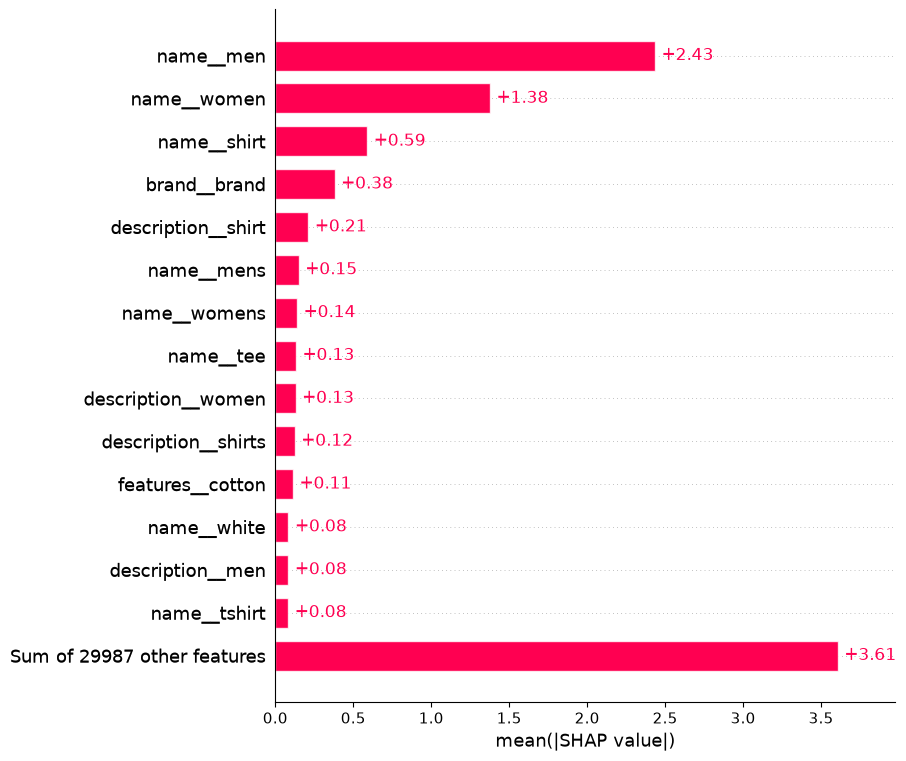

In [20]:
deigma_lathon = examples.head(50)
transformed_rows = model["features"].transform(deigma_lathon).toarray()

shap_values_deigmatos = explainer(transformed_rows)
shap_values_deigmatos.feature_names = list(feature_names)

print("proionta sto deigma:", len(deigma_lathon))
shap.plots.bar(shap_values_deigmatos[:, :, thesi_preds], max_display=15)

Η Eπιδραστικότητα της καθε λεξης στο σύνολο των δειγμάτων(50). 


## 8. Αποθήκευση μοντέλου

In [21]:
joblib.dump(calibrated_model, "../../model_storage/calibrated_model.joblib")
print("saved: model_storage/calibrated_model.joblib")

saved: model_storage/calibrated_model.joblib
